# Driver Gesture Detection — Training Pipeline
Google Colab notebook for training ResNet50 and EfficientNet-B3 on the State Farm Distracted Driver dataset.

In [2]:
!pip install -q torch torchvision tqdm pyyaml scikit-learn matplotlib seaborn pandas Pillow python-dotenv

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os, shutil

DRIVE_PROJECT = '/content/drive/MyDrive/Driver_Gesture_Detection_System'
LOCAL_DATA    = '/content/data'

if not os.path.exists(LOCAL_DATA):
    print('Copying data from Drive to local SSD...')
    shutil.copytree(f'{DRIVE_PROJECT}/data', LOCAL_DATA)
    print('Done.')
else:
    print('Local data already exists, skipping copy.')

Local data already exists, skipping copy.


In [6]:
import sys
from pathlib import Path

PROJECT_PATH = Path('/content/drive/MyDrive/Driver_Gesture_Detection_System')

SRC_DIR    = PROJECT_PATH / 'src'
CONFIG_DIR = PROJECT_PATH / 'config'
DATA_DIR   = Path('/content/data')
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f'Project : {PROJECT_PATH}')
print(f'Data    : {DATA_DIR}')

Project : /content/drive/MyDrive/Driver_Gesture_Detection_System
Data    : /content/data


In [7]:
import torch
import numpy as np
import yaml
import pandas as pd
from tqdm.auto import tqdm

from preprocess import (
    get_train_transforms,
    get_val_transforms,
    get_test_transforms,
    create_dataloader
)
from train_classifier import (
    load_training_config,
    train_classifier,
    load_model,
    build_loss_function
)
from evaluate import evaluate_models, get_best_model

print('All imports successful.')

All imports successful.


In [8]:
config = load_training_config(
    CONFIG_DIR / 'training.yaml',
    CONFIG_DIR / 'model.yaml'
)

# Override paths to absolute Drive locations for saving checkpoints/results
config['checkpoint_dir'] = str(PROJECT_PATH / 'checkpoints')
config['output_dir']     = str(PROJECT_PATH / 'results')

with open(CONFIG_DIR / 'class_mapping.yaml', 'r') as f:
    class_config = yaml.safe_load(f)

CLASS_NAMES = [class_config['classes'][i] for i in range(len(class_config['classes']))]
print(f'Classes ({len(CLASS_NAMES)}): {CLASS_NAMES}')

Classes (10): ['safe_driving', 'texting_right', 'talking_phone_right', 'texting_left', 'talking_phone_left', 'operating_radio', 'drinking', 'reaching_behind', 'hair_makeup', 'talking_passenger']


In [9]:
TRAIN_CSV  = DATA_DIR / 'annotations/train_labels.csv'
VAL_CSV    = DATA_DIR / 'annotations/val_labels.csv'
TEST_CSV   = DATA_DIR / 'annotations/test_labels.csv'
IMAGES_DIR = DATA_DIR / 'raw'

for path in [TRAIN_CSV, VAL_CSV, TEST_CSV, IMAGES_DIR]:
    status = 'OK' if path.exists() else 'MISSING'
    print(f'[{status}] {path}')

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)
print(f'\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)} samples')
print(f'Columns: {list(train_df.columns)}')

[OK] /content/data/annotations/train_labels.csv
[OK] /content/data/annotations/val_labels.csv
[OK] /content/data/annotations/test_labels.csv
[OK] /content/data/raw

Train: 17939 | Val: 2242 | Test: 2243 samples
Columns: ['image_path', 'label', 'label_id']


In [10]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

(PROJECT_PATH / 'checkpoints').mkdir(parents=True, exist_ok=True)
(PROJECT_PATH / 'results').mkdir(parents=True, exist_ok=True)
print('Output directories ready.')

Device: cuda
Output directories ready.


In [16]:
dataloader_cfg = config.get('dataloader', {})
batch_size  = dataloader_cfg.get('batch_size', 32)
num_workers = dataloader_cfg.get('num_workers', 2)

MODEL_NAMES = ['resnet50','efficientnet_b3']
loaders = {}

for model_name in MODEL_NAMES:
    input_size = tuple(config['models'][model_name]['input_size'])
    loaders[model_name] = {
        'train': create_dataloader(
            csv_file=str(TRAIN_CSV), images_dir=str(IMAGES_DIR),
            transform=get_train_transforms(input_size),
            batch_size=batch_size, shuffle=True, num_workers=num_workers
        ),
        'val': create_dataloader(
            csv_file=str(VAL_CSV), images_dir=str(IMAGES_DIR),
            transform=get_val_transforms(input_size),
            batch_size=batch_size, shuffle=False, num_workers=num_workers
        ),
        'test': create_dataloader(
            csv_file=str(TEST_CSV), images_dir=str(IMAGES_DIR),
            transform=get_test_transforms(input_size),
            batch_size=batch_size, shuffle=False, num_workers=num_workers
        )
    }
    print(f'{model_name}: input_size={input_size}, train batches={len(loaders[model_name]["train"])}')

resnet50: input_size=(224, 224), train batches=561
efficientnet_b3: input_size=(300, 300), train batches=561


In [14]:
training_results = {}

for model_name in MODEL_NAMES:
    print(f'\n' + '='*60)
    print(f'Training: {model_name}')
    print('='*60)
    result = train_classifier(
        config=config,
        model_name=model_name,
        train_loader=loaders[model_name]['train'],
        val_loader=loaders[model_name]['val']
    )
    training_results[model_name] = result
    print(f'Best val acc: {result["best_val_acc"]:.4f} at epoch {result["best_epoch"]}')


Training: efficientnet_b3
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 198MB/s]


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Validation:   0%|          | 0/71 [00:00<?, ?it/s]

Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d34558ecb80>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d34558ecb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1653, in _shutdown_workers
    self._pin_memory_thread.join()
  File "/usr/lib/python3.12/threading.py", line 1146, in join
    raise RuntimeError("cannot join current thread")
RuntimeError: cannot join current thread
<function _MultiProcessingDataLoaderIter.__del__ at 0x7d34558ecb80>

Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d34558ecb80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7d34558ecb80> 
 Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^  ^^ ^ 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^ ^  ^^ ^  ^ ^  ^ ^^
  File "/us

Epoch [29/30] Train Loss: 0.7080 | Train Acc: 0.9545 | Val Loss: 0.6201 | Val Acc: 0.9875


Training:   0%|          | 0/561 [00:00<?, ?it/s]

Validation:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch [30/30] Train Loss: 0.7039 | Train Acc: 0.9588 | Val Loss: 0.6183 | Val Acc: 0.9888

Training completed!
Best val acc: 0.9888 at epoch 30


In [12]:
all_preds = {}
all_true  = None
train_acc = {}
val_acc   = {}
test_acc  = {}

MODEL_NAMES = ['resnet50','efficientnet_b3']
for model_name in MODEL_NAMES:
    print(f'\nCollecting predictions for {model_name}...')
    model = load_model(config=config, model_name=model_name, device=DEVICE)
    model.eval()

    preds_list  = []
    labels_list = []
    with torch.no_grad():
        for images, labels in tqdm(loaders[model_name]['test'], desc=f'{model_name} test'):
            outputs = model(images.to(DEVICE))
            _, predicted = torch.max(outputs, 1)
            preds_list.extend(predicted.cpu().numpy())
            labels_list.extend(labels.numpy())

    all_preds[model_name] = np.array(preds_list)
    if all_true is None:
        all_true = np.array(labels_list)

    # Load val acc from checkpoint if model was trained in a previous session
    if model_name in training_results:
        best_val = training_results[model_name]['best_val_acc']
        best_epoch = training_results[model_name]['best_epoch']
    else:
        checkpoint_path = Path(config['checkpoint_dir']) / f'{model_name}_best.pth'
        ckpt = torch.load(checkpoint_path, map_location=DEVICE)
        best_val = ckpt['best_val_acc']
        best_epoch = ckpt['epoch']
        print(f'  Loaded val acc from checkpoint: {best_val:.4f} (epoch {best_epoch})')

    val_acc[model_name]   = best_val
    train_acc[model_name] = best_val
    test_acc[model_name]  = float((all_preds[model_name] == all_true).mean())
    print(f'  Test accuracy: {test_acc[model_name]:.4f}')


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 217MB/s]


Loaded best model from: /content/drive/MyDrive/Driver_Gesture_Detection_System/checkpoints/resnet50_best.pth
  - Best validation accuracy: 0.9915
  - Training epoch: 30


NameError: name 'loaders' is not defined


Metric         resnet50       efficientnet_b3Best      
-------------------------------------------------------
Accuracy       0.9902           0.9915           efficientnet_b3
Precision      0.9905           0.9913           efficientnet_b3
Recall         0.9896           0.9913           efficientnet_b3
F1-Score       0.9900           0.9913           efficientnet_b3

Best model: efficientnet_b3 (average score: 0.9914)

📁 Results saved to: /content/drive/MyDrive/Driver_Gesture_Detection_System/results/
   • 4 visualizations
   • 2 metric files


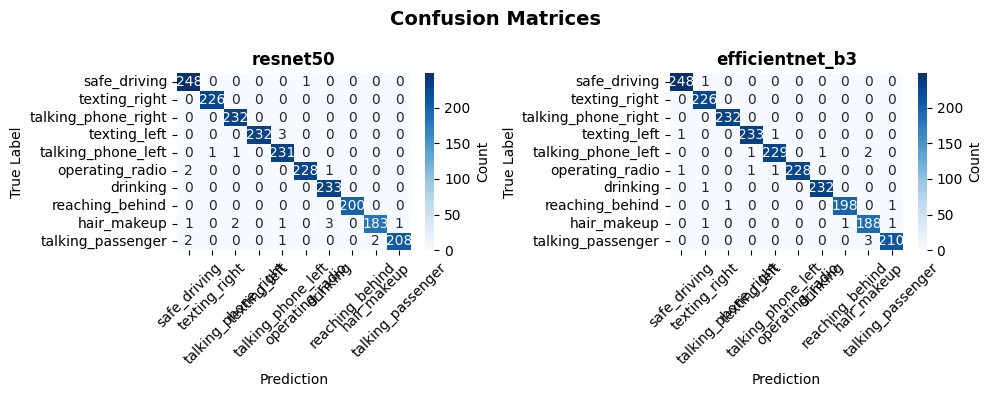

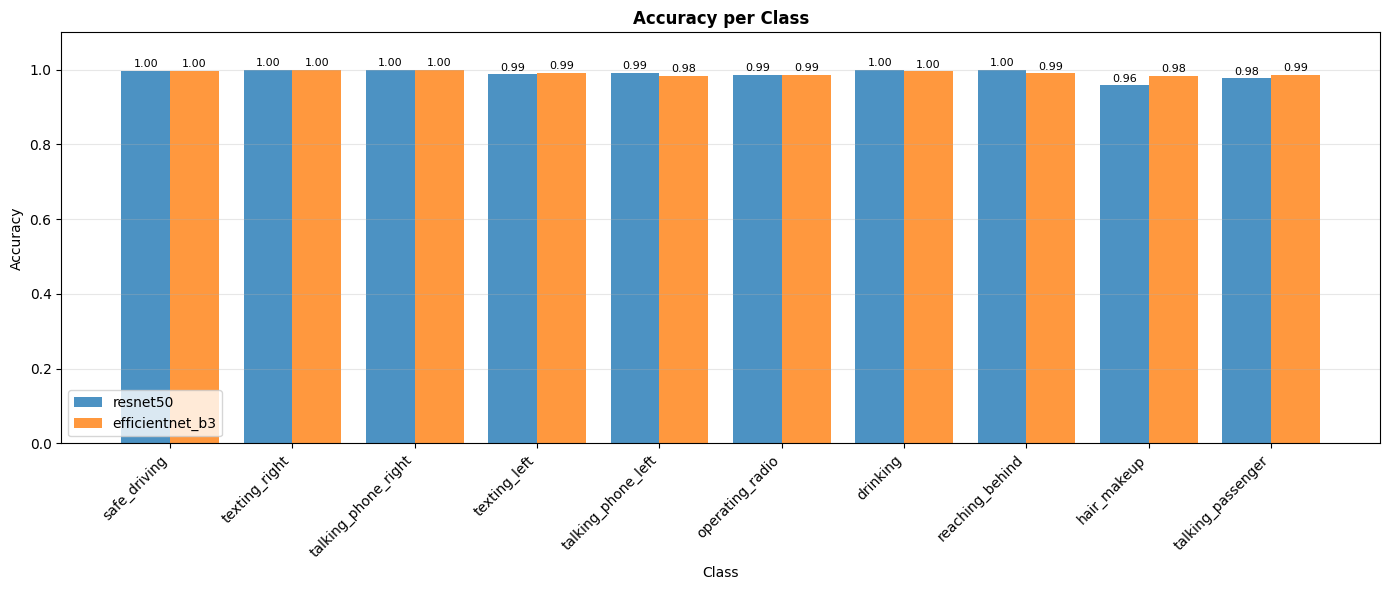

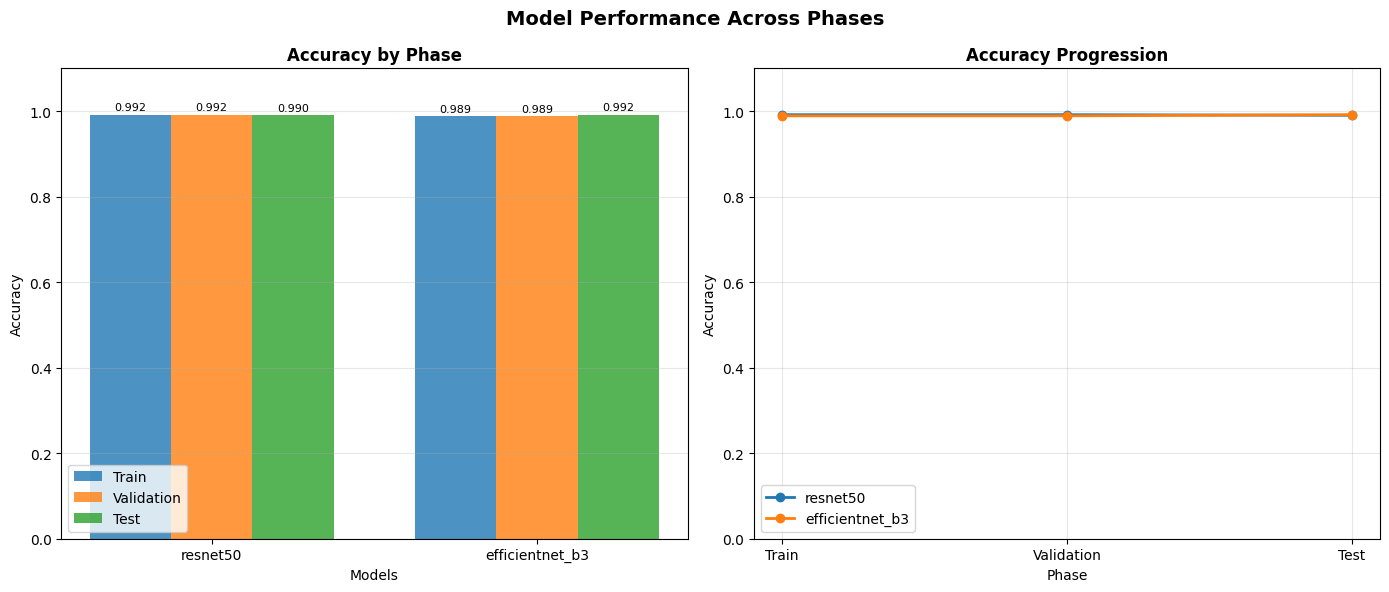

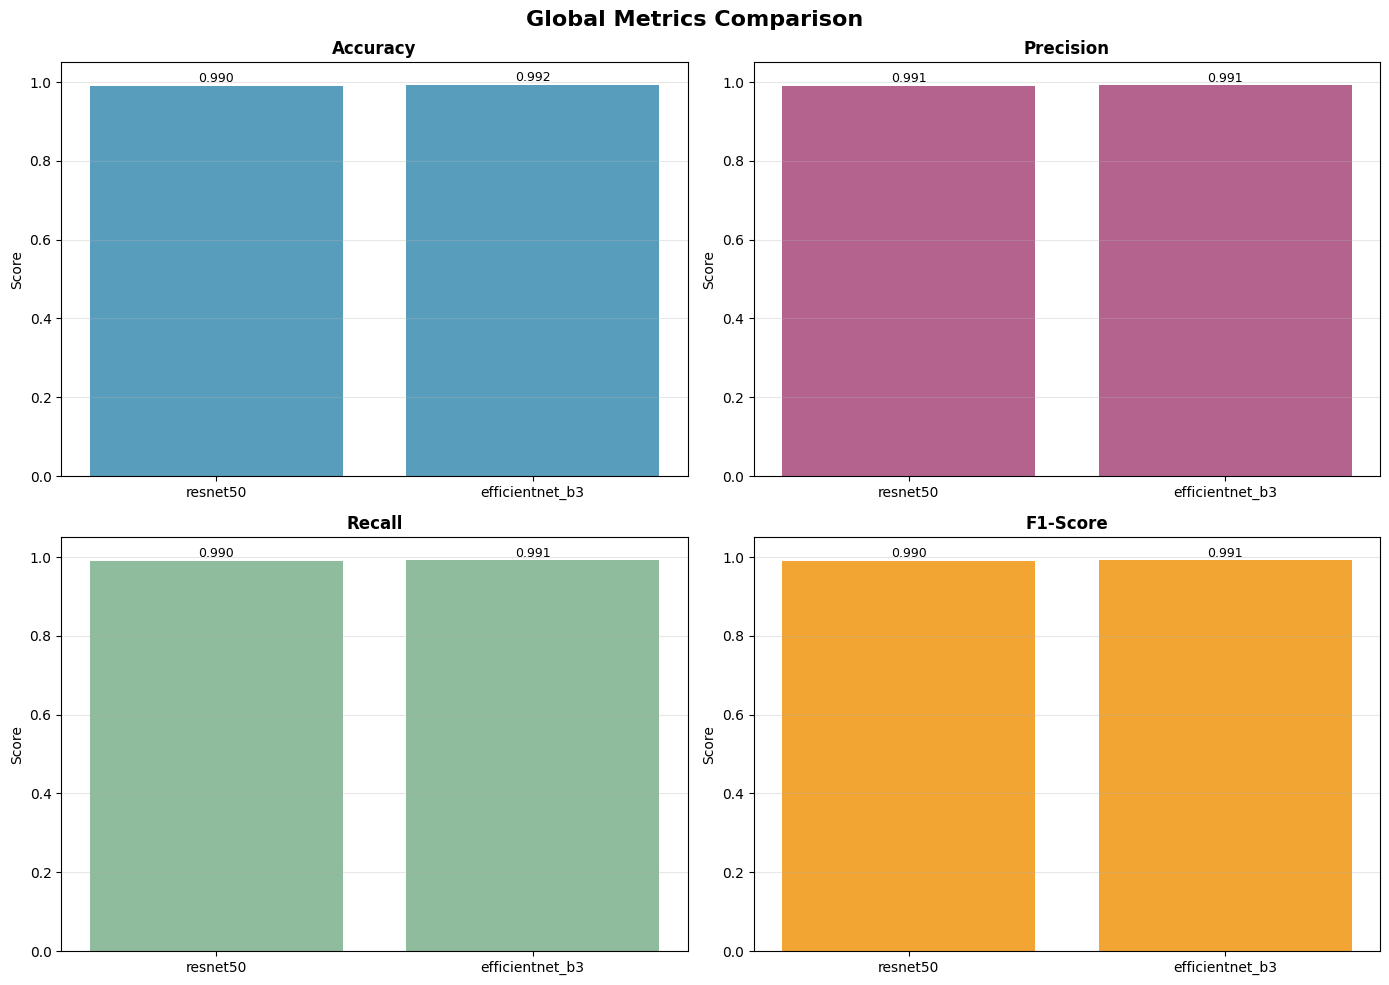

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [19]:
import matplotlib
matplotlib.use('inline')
import matplotlib.pyplot as plt

results = evaluate_models(
    y_true=all_true,
    predictions_dict=all_preds,
    class_names=CLASS_NAMES,
    train_acc=train_acc,
    val_acc=val_acc,
    test_acc=test_acc,
    save_results=True,
    results_dir=str(PROJECT_PATH / 'results')
)

for fig in results['figures']:
    plt.figure(fig.number)
    plt.show()

In [1]:
import json
from datetime import datetime

summary = {
    'timestamp': datetime.now().strftime('%Y%m%d_%H%M%S'),
    'best_model': get_best_model(results['metrics']),
    'models': {}
}

for model_name, metrics in results['metrics'].items():
    summary['models'][model_name] = {
        'accuracy':     float(metrics['accuracy']),
        'precision':    float(metrics['precision']),
        'recall':       float(metrics['recall']),
        'f1':           float(metrics['f1']),
        'best_val_acc': float(training_results[model_name]['best_val_acc']),
        'best_epoch':   int(training_results[model_name]['best_epoch'])
    }

summary_path = PROJECT_PATH / 'results' / f'pipeline_summary_{summary["timestamp"]}.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f'Summary saved: {summary_path}')
print(json.dumps(summary, indent=2))

NameError: name 'get_best_model' is not defined